In [ ]:
import numpy as np
import pandas as pd

: 

In [ ]:
df = pd.read_pickle("../cache/cons_evaluations/exports/rfc_results_n1000_w1_3_5_10_bias0_1_2.pkl")
df = df.loc[df.eval_type == "test"]
df = df.loc[~df.algorithm_slug.str.contains("\?")]
df

,algorithm_slug,algorithm_family,algorithm_file,w_size,eval_type,group_size,groups_count,run_num,group_type,bias,...,ndcg_5_ndcg_com_mean_overall,ndcg_10_per_user_ndcg_mean_overall,ndcg_10_ndcg_com_mean_overall,ndcg_20_per_user_ndcg_mean_overall,ndcg_20_ndcg_com_mean_overall,ndcg_50_per_user_ndcg_mean_overall,ndcg_50_ndcg_com_mean_overall,ndcg_100_per_user_ndcg_mean_overall,ndcg_100_ndcg_com_mean_overall,first_consensus_global_position_across_groups
0,A0,async,eval_async_static_policy_simple_priority_funct...,1,test,NaN,100,1,similar,0.0,...,0.500836,0.614,0.498293,0.574773,0.461216,0.513981,0.445869,0.488691,0.501763,NaN
1,A0,async,eval_async_static_policy_simple_priority_funct...,1,test,NaN,100,1,similar,1.0,...,NaN,NaN,NaN,0.573408,0.460018,NaN,NaN,NaN,NaN,19.062500
2,A0,async,eval_async_static_policy_simple_priority_funct...,1,test,NaN,100,1,similar,2.0,...,NaN,NaN,NaN,0.580614,0.485203,NaN,NaN,NaN,NaN,29.380952
3,A0,async,eval_async_static_policy_simple_priority_funct...,1,test,NaN,100,1,outlier,0.0,...,0.500836,0.614,0.498293,0.574773,0.461216,0.513981,0.445869,0.488691,0.501763,NaN
4,A0,async,eval_async_static_policy_simple_priority_funct...,1,test,NaN,100,1,outlier,1.0,...,NaN,NaN,NaN,0.578677,0.467107,NaN,NaN,NaN,NaN,14.381443
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
291,S1,sync,eval_sync_with_feedback_ema.py,5,test,NaN,100,1,similar,1.0,...,NaN,NaN,NaN,0.575617,0.463458,NaN,NaN,NaN,NaN,16.781250
292,S1,sync,eval_sync_with_feedback_ema.py,5,test,NaN,100,1,outlier,0.0,...,NaN,NaN,NaN,0.575992,0.465465,NaN,NaN,NaN,NaN,4.280000
293,S1,sync,eval_sync_with_feedback_ema.py,5,test,NaN,100,1,outlier,1.0,...,NaN,NaN,NaN,0.581088,0.469979,NaN,NaN,NaN,NaN,17.104167
294,S1,sync,eval_sync_with_feedback_ema.py,5,test,NaN,100,1,random,0.0,...,NaN,NaN,NaN,0.575827,0.464112,NaN,NaN,NaN,NaN,5.450000


In [28]:
df.average.unique()

array([ 4.08      , 19.0625    , 29.38095238,  4.89      , 14.3814433 ,
       38.62      ,  4.25      , 19.13829787, 25.2745098 , 36.95294118,
       49.55357143, 54.33333333, 37.68965517, 47.69230769, 55.3125    ,
       37.44186047, 46.74137931, 52.26666667,  3.59      ,  9.72      ,
       26.62121212,  3.52      , 11.48979592, 27.63888889,  3.68      ,
       10.28865979, 29.43835616,  9.81818182,  3.23      , 28.45833333,
       12.79591837,  3.45      , 26.66197183, 10.97      ,  2.89      ,
       23.28169014, 11.50505051, 12.4040404 , 13.3       ,  4.11      ,
       14.07291667, 29.11538462,  3.89      , 14.15053763, 34.21568627,
        4.76      , 16.63829787, 33.07692308,  3.53      , 17.36458333,
       31.23913043,  4.73      , 17.96842105, 39.71698113,  4.76767677,
       14.86458333, 30.91666667,  4.96875   ,  2.1       ,  2.72      ,
        1.15      ,  2.67676768,  4.        ,  1.07      ,  2.61616162,
        3.49090909,  1.26      ,  2.6122449 ,  3.2       ,  1.88

In [29]:
df.columns

Index(['algorithm_slug', 'algorithm_family', 'algorithm_file', 'w_size',
       'eval_type', 'group_size', 'groups_count', 'run_num', 'group_type',
       'bias', 'average', 'variance', 'std_dev', 'cache_path', 'bias_raw',
       'ndcg_5_per_user_ndcg_mean_overall', 'ndcg_5_ndcg_com_mean_overall',
       'ndcg_10_per_user_ndcg_mean_overall', 'ndcg_10_ndcg_com_mean_overall',
       'ndcg_20_per_user_ndcg_mean_overall', 'ndcg_20_ndcg_com_mean_overall',
       'ndcg_50_per_user_ndcg_mean_overall', 'ndcg_50_ndcg_com_mean_overall',
       'ndcg_100_per_user_ndcg_mean_overall', 'ndcg_100_ndcg_com_mean_overall',
       'first_consensus_global_position_across_groups'],
      dtype='object')

In [30]:
df.shape

(242, 26)

In [31]:
df = df.dropna(subset="average")
df.shape

(242, 26)

In [34]:
df.loc[df.w_size == 5].groupby(["w_size","bias","algorithm_slug"])[["first_consensus_global_position_across_groups"]].mean()

first_consensus_global_position_across_groups
w_size bias algorithm_slug                                               
5      0.0  A0                                                   4.837165
            A1                                                   8.571111
            A2                                                   9.304792
            H0                                                   4.155000
            H1                                                   4.513333
            S0                                                   4.200000
            S1                                                   5.100000
       1.0  A0                                                  14.338598
            A1                                                  14.439158
            A2                                                  15.282222
            H0                                                  13.359147
            H1                                                  15.695286
            S0                                                  14.876855
            S1                                                  16.171025
       2.0  A0                                                  31.080993
            A1                                                  32.784416
            A2                                                  29.099573
            H0                                                  32.436888
            S0                                                  30.597801

In [23]:
df.loc[df.w_size == 5].groupby(["w_size","bias","group_type","algorithm_slug"])[["first_consensus_global_position_across_groups"]].mean()

first_consensus_global_position_across_groups
w_size bias group_type algorithm_slug                                               
5      0.0  outlier    A0                                                   3.780000
                       A1                                                   8.250000
                       A2                                                   8.090000
                       H0                                                   4.115000
                       H1                                                   4.625000
                       S0                                                   3.670000
                       S1                                                   4.280000
            random     A0                                                   5.689330
                       A1                                                   8.725000
                       A2                                                  10.430417
                       H0                                                   3.920000
                       H1                                                   4.720000
                       S0                                                   4.040000
                       S1                                                   5.450000
            similar    A0                                                   4.190000
                       A1                                                   8.738333
                       A2                                                   8.268333
                       H0                                                   4.430000
                       H1                                                   4.195000
                       S0                                                   4.890000
                       S1                                                   5.570000
       1.0  outlier    A0                                                  14.172043
                       A1                                                  15.590000
                       A2                                                  15.296667
                       H0                                                  14.836700
                       H1                                                  16.373737
                       S0                                                  16.021053
                       S1                                                  17.104167
            random     A0                                                  14.093750
                       A1                                                  12.980000
                       A2                                                  15.770000
                       H0                                                  11.601010
                       H1                                                  14.823232
                       S0                                                  13.924731
                       S1                                                  14.627660
            similar    A0                                                  14.750000
                       A1                                                  14.747475
                       A2                                                  14.780000
                       H0                                                  13.639731
                       H1                                                  15.888889
                       S0                                                  14.684783
                       S1                                                  16.781250
       2.0  outlier    A0                                                  29.744681
                       A1                                                  32.069444
                       A2                                                  24.425373
                       H0                   

In [35]:
df.groupby(["w_size","bias","group_type"])[["average"]].mean()

average
w_size bias group_type           
1      0.0  outlier      9.694943
            random       9.631590
            similar      9.248824
       1.0  outlier     18.697495
            random      18.848745
            similar     18.728115
       2.0  outlier     37.027671
            random      32.375802
            similar     33.191391
3      0.0  outlier      1.960000
            random       1.912857
            similar      2.045859
       1.0  outlier      5.067899
            random       4.838588
            similar      4.907407
       2.0  outlier     11.358366
            random      10.367538
            similar     10.869283
5      0.0  outlier      1.575714
            random       1.831145
            similar      1.665714
       1.0  outlier      3.512744
            random       3.192107
            similar      3.389588
       2.0  outlier      6.050826
            random       6.752341
            similar      6.939191
10     0.0  outlier      1.374286
            random       1.964875
            similar      1.375714
       1.0  outlier      2.333720
            random       2.212088
            similar      2.228341
       2.0  outlier      3.760580
            random       3.524182
            similar      3.822205

In [66]:
import seaborn as sns
from matplotlib import pyplot as plt

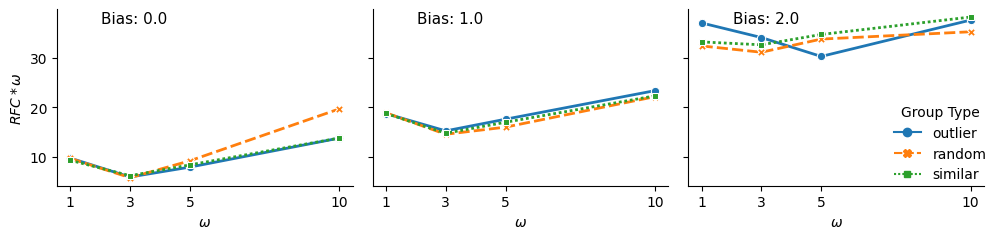

In [79]:
dfx = df.groupby(["w_size","bias","group_type"])[["average"]].mean().reset_index()
dfx["avg_w"] = dfx["average"]* dfx["w_size"]
g = sns.FacetGrid(dfx, col="bias", legend_out=True, height=2.5, aspect=1.2 )
g.map_dataframe(sns.lineplot, x="w_size", y="avg_w", hue="group_type", style="group_type", markers=True,  linewidth=2)
g.add_legend(
    title="Group Type",
    bbox_to_anchor=(1.00, 0.20),
    loc="lower right")



g.axes[0,0].set_ylabel(r'$RFC * \omega$')
g.axes[0,0].set_xlabel(r'$\omega$')
g.axes[0,1].set_xlabel(r'$\omega$')
g.axes[0,2].set_xlabel(r'$\omega$')

g.axes[0,0].set_xticks([1,3,5,10])
g.axes[0,1].set_xticks([1,3,5,10])
g.axes[0,2].set_xticks([1,3,5,10])

g.set_titles("")

# add titles inside each subplot
for ax, title in zip(g.axes.flat, g.col_names):
    ax.text(
        0.15, 0.99, f"Bias: {title}",   # position (x,y) in axes coords
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=11
    )

plt.tight_layout()
plt.savefig("results_per_grouptype.pdf", bbox_inches='tight')